In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt


def quat_to_yaw(w, x, y, z):
    yaw_rad = math.atan2(2 * (w * z + x * y), 1 - 2 * (y**2 + z**2))
    yaw_deg = math.degrees(yaw_rad)
    return yaw_deg


def unwrap_angles(angles_deg):
    angles_rad = np.deg2rad(angles_deg)
    unwrapped_rad = np.unwrap(angles_rad)
    unwrapped_deg = np.rad2deg(unwrapped_rad)
    return unwrapped_deg

def compute_mean_absolute_offset(estimated, true):
    diff = np.abs(estimated - true)
    return np.mean(diff)

df_imu_f2 = pd.read_csv('f2_imu_eval.csv')
df_tele_f2 = pd.read_csv('f2.csv')

merged_f2 = pd.merge(df_tele_f2, df_imu_f2, how='inner', left_on=['c1_frame', 'c2_frame'], right_on=['c1_frame', 'c2_frame'])


merged_f2['c1_yaw_quat'] = merged_f2.apply(lambda row: quat_to_yaw(row['c1_CORI_0'], row['c1_CORI_1'], row['c1_CORI_2'], row['c1_CORI_3']), axis=1)
merged_f2['c2_yaw_quat'] = merged_f2.apply(lambda row: quat_to_yaw(row['c2_CORI_0'], row['c2_CORI_1'], row['c2_CORI_2'], row['c2_CORI_3']), axis=1)


merged_f2['c1_yaw_unwrapped'] = unwrap_angles(merged_f2['c1_yaw'])
merged_f2['c2_yaw_unwrapped'] = unwrap_angles(merged_f2['c2_yaw'])
merged_f2['c1_yaw_quat_unwrapped'] = unwrap_angles(merged_f2['c1_yaw_quat'])
merged_f2['c2_yaw_quat_unwrapped'] = unwrap_angles(merged_f2['c2_yaw_quat'])


merged_f2['avg_yaw_imu_unwrapped'] = (merged_f2['c1_yaw_unwrapped'] + merged_f2['c2_yaw_unwrapped']) / 2
merged_f2['avg_yaw_quat_unwrapped'] = (merged_f2['c1_yaw_quat_unwrapped'] + merged_f2['c2_yaw_quat_unwrapped']) / 2




Found 2 OUTBOUND groups


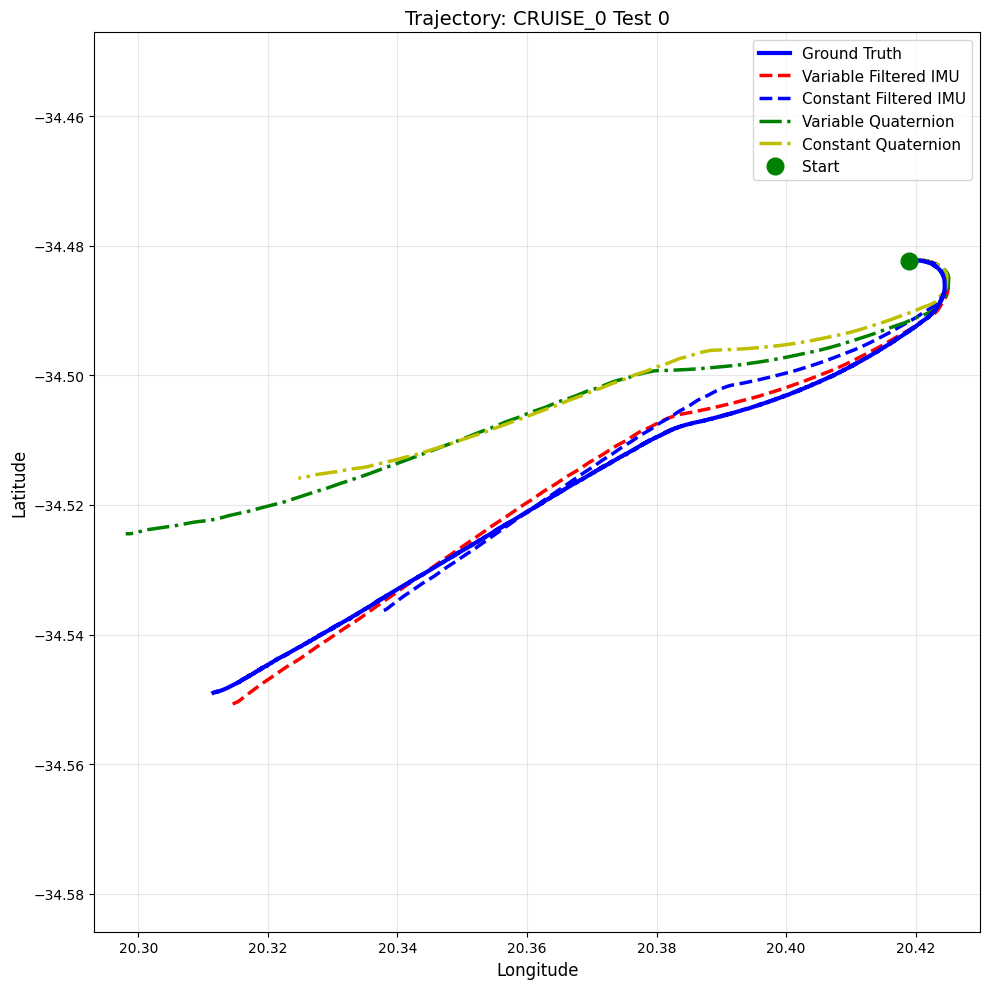

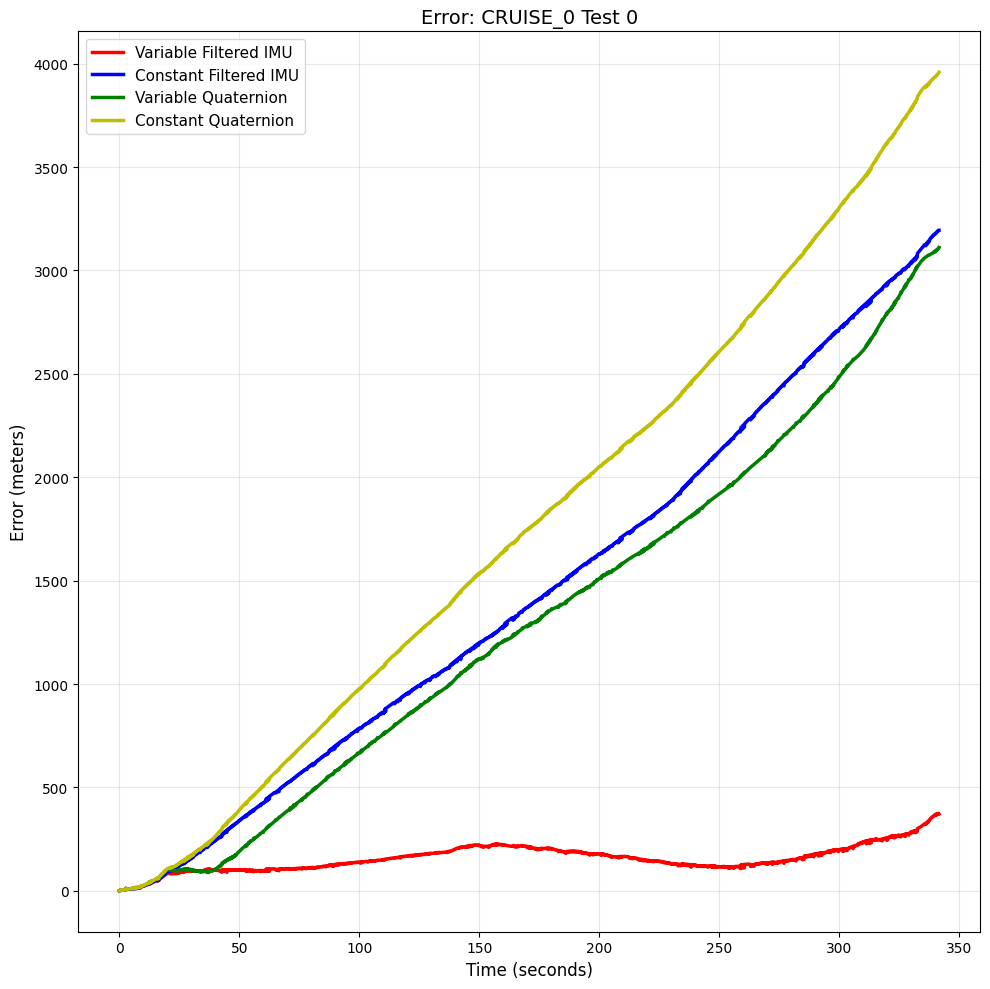


CRUISE_0 Test 0:
                         5s   10s    30s   1min  2.5min    5min  10min  15min  20min    Mean   Final
Variable Filtered IMU  10.0  22.0   97.0   93.0   218.0   199.0      -      -      -   156.0   372.0
Constant Filtered IMU  10.0  22.0  160.0  422.0  1199.0  2719.0      -      -      -  1439.0  3195.0
Variable Quaternion    11.0  25.0  100.0  283.0  1121.0  2487.0      -      -      -  1310.0  3111.0
Constant Quaternion    11.0  25.0  171.0  504.0  1537.0  3306.0      -      -      -  1781.0  3959.0


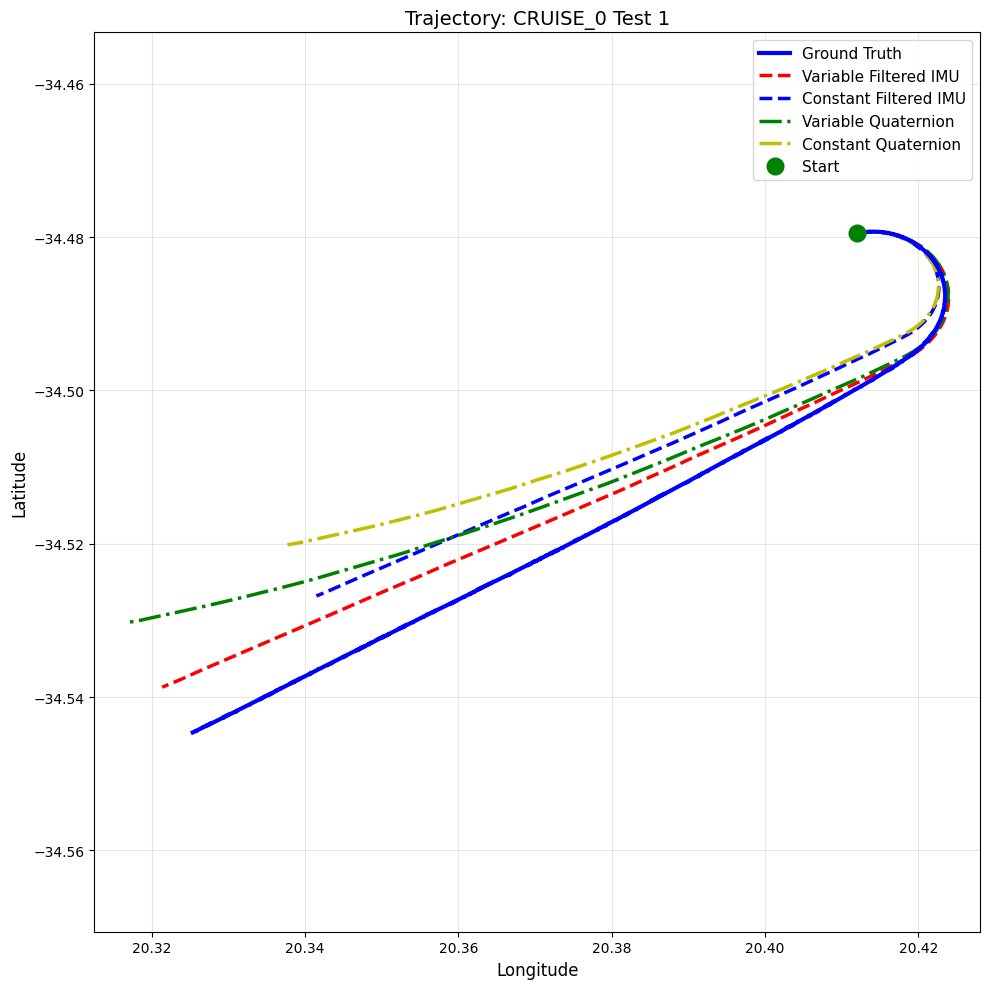

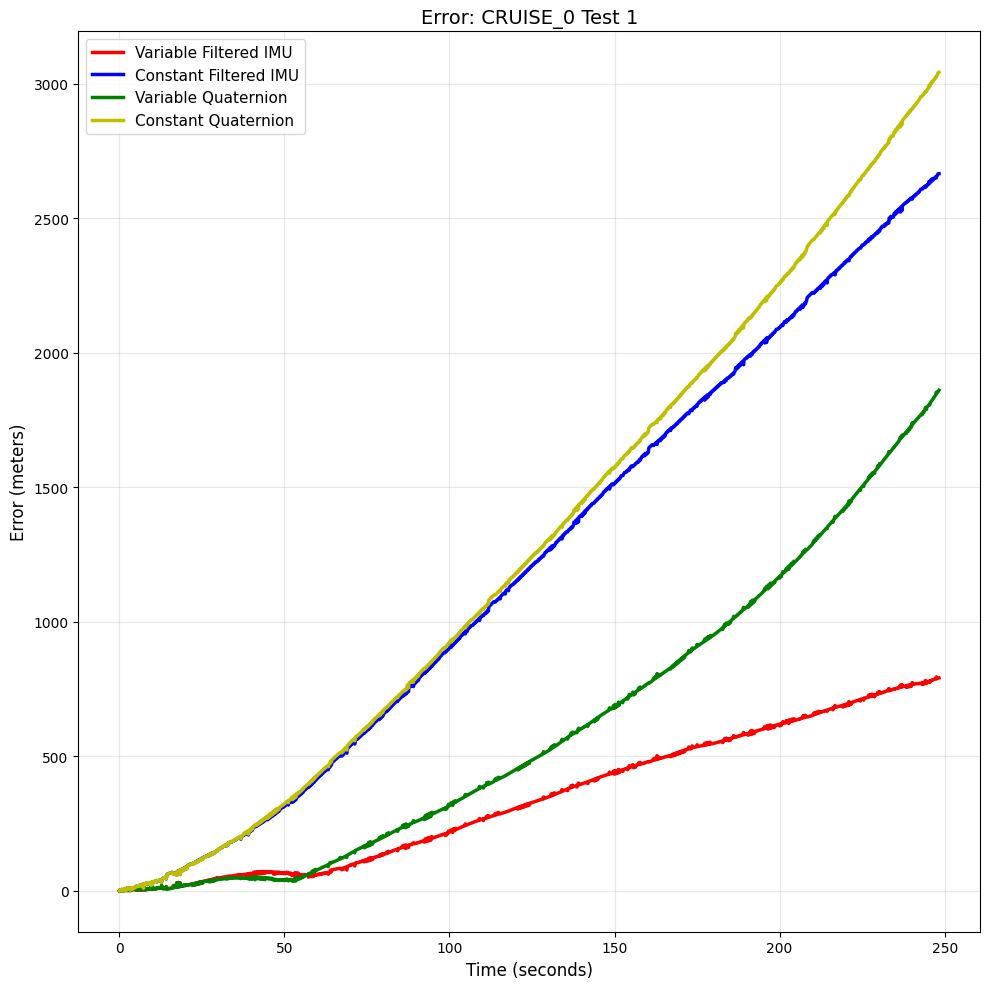


CRUISE_0 Test 1:
                         5s   10s    30s   1min  2.5min  5min  10min  15min  20min    Mean   Final
Variable Filtered IMU   3.0  16.0   48.0   60.0   434.0     -      -      -      -   341.0   791.0
Constant Filtered IMU  16.0  23.0  155.0  419.0  1513.0     -      -      -      -  1213.0  2665.0
Variable Quaternion     3.0  16.0   43.0   79.0   678.0     -      -      -      -   611.0  1861.0
Constant Quaternion    17.0  23.0  155.0  430.0  1572.0     -      -      -      -  1295.0  3042.0
Found 1 OUTBOUND groups


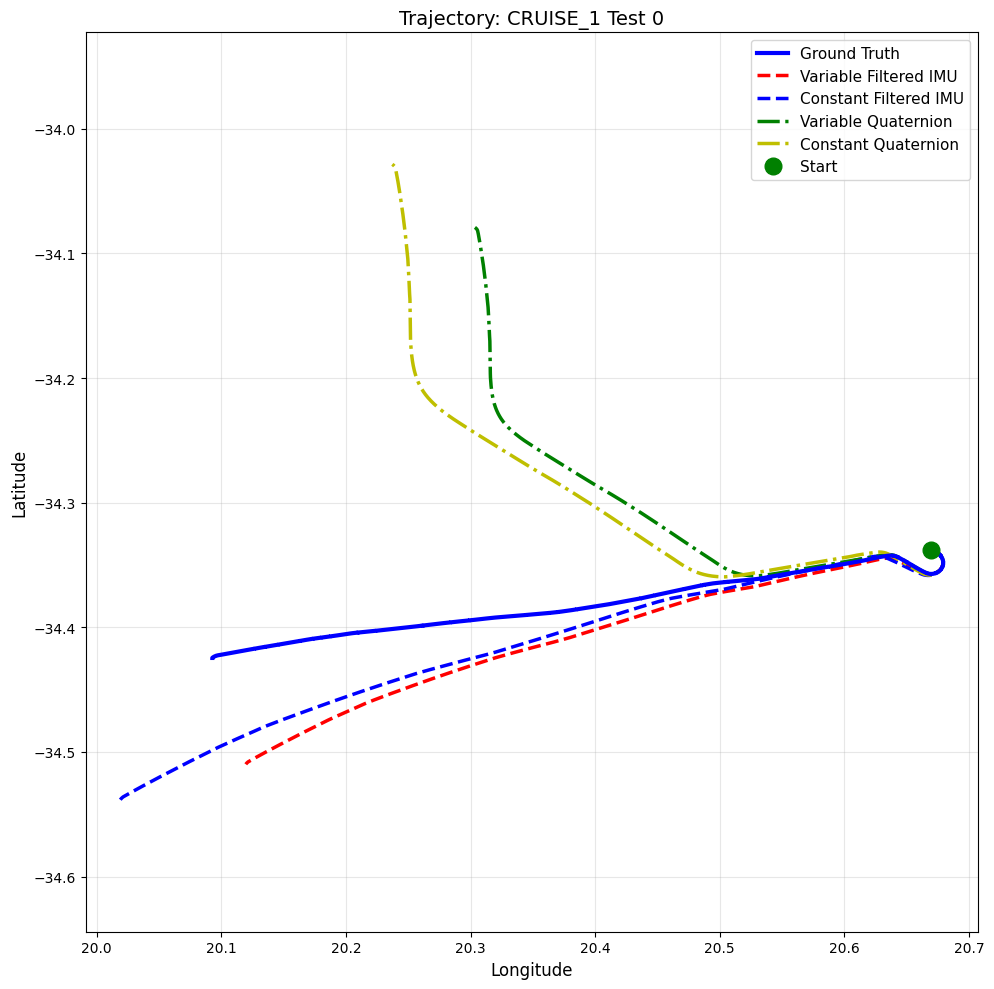

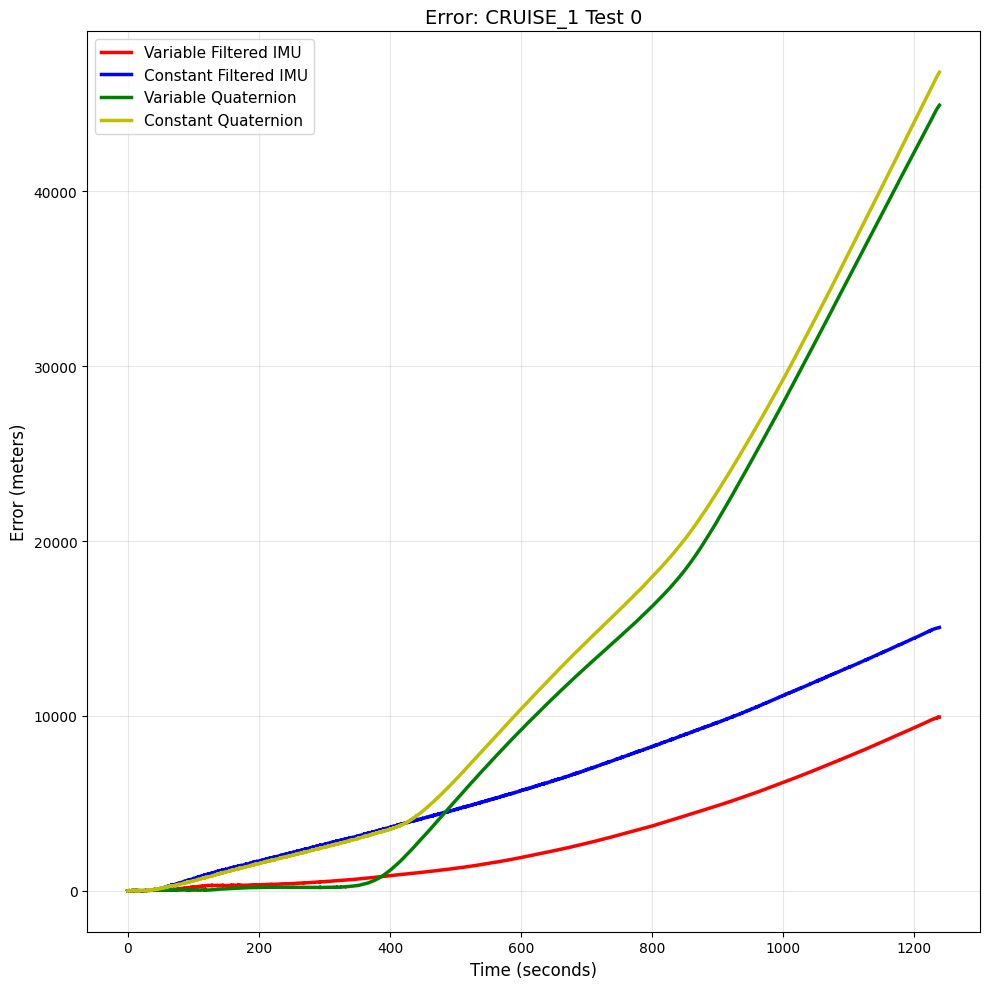


CRUISE_1 Test 0:
                        5s  10s   30s   1min  2.5min    5min    10min    15min    20min     Mean    Final
Variable Filtered IMU  6.0  9.0  21.0   47.0   301.0   526.0   1904.0   4873.0   9327.0   3101.0   9929.0
Constant Filtered IMU  6.0  8.0  25.0  240.0  1230.0  2667.0   5723.0   9620.0  14457.0   6481.0  15058.0
Variable Quaternion    6.0  8.0  17.0   45.0   113.0   198.0   9203.0  21197.0  42259.0  13385.0  44924.0
Constant Quaternion    6.0  8.0  23.0  224.0  1079.0  2503.0  10392.0  22849.0  43972.0  14832.0  46808.0


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class DeadReckoning:
    def __init__(self, df, state='CRUISE_0'):
        self.df = df[df['STATE'] == state].copy()
        self.state = state
        self.segments = []
        self.extract_segments()

    def extract_segments(self):
        outbound_groups = []
        current_start = None
        for idx, (i, row) in enumerate(self.df.iterrows()):
            if row['SUBSTATE'] == 'OUTBOUND':
                if current_start is None:
                    current_start = i
            elif current_start is not None:
                outbound_groups.append((current_start, self.df.index[idx-1]))
                current_start = None
        if current_start is not None:
            outbound_groups.append((current_start, self.df.index[-1]))
        print(f"Found {len(outbound_groups)} OUTBOUND groups")

        for test_num, (out_start, out_end) in enumerate(outbound_groups):
            outbound = self.df.loc[out_start:out_end].copy()
            after = self.df[self.df.index > out_end]
            turning = after[after['SUBSTATE'] == 'TURNING']
            if len(turning) > 0:
                turn_idx = turning.index[0]
                inbound = self.df[(self.df.index > turn_idx) & (self.df['SUBSTATE'] == 'INBOUND')]
                if len(inbound) > 0:
                    inb_start = inbound.index[0]
                    inb_after = self.df[self.df.index >= inb_start]
                    for j, (i, row) in enumerate(inb_after.iterrows()):
                        if row['SUBSTATE'] != 'INBOUND':
                            inb_end = inb_after.index[j-1]
                            break
                    else:
                        inb_end = inb_after.index[-1]
                    self.segments.append({
                        'num': test_num,
                        'outbound': outbound,
                        'test': self.df.loc[turn_idx:inb_end].copy()
                    })

    def calibrate(self, seg, yaw_col, n_samples=None):
        outbound = seg['outbound'].tail(n_samples) if n_samples else seg['outbound']
        if len(outbound) == 0:
            return 0.0
        heading = outbound['HEADING'].values
        yaw = outbound[yaw_col].values
        offset = (heading - (-yaw)).mean()
        return ((offset + 180) % 360) - 180

    def integrate(self, seg, yaw_col='avg_yaw_imu_unwrapped', n_calib=None, avg_speed=False):
        offset = self.calibrate(seg, yaw_col, n_calib)
        test = seg['test']
        speed = seg['outbound']['GND_SPD_MS'].mean() if avg_speed and len(seg['outbound']) > 0 else None
        pos = [[test.iloc[0]['LATITUDE'], test.iloc[0]['LONGITUDE']]]
        for i in range(1, len(test)):
            prev, curr = test.iloc[i-1], test.iloc[i]
            heading = np.radians(-prev[yaw_col] + offset)
            dt = curr['TIME'] - prev['TIME']
            dist = (speed if speed else prev['GND_SPD_MS']) * dt
            dlat = (dist / 111000) * np.cos(heading)
            dlon = (dist / (111000 * np.cos(np.radians(pos[-1][0])))) * np.sin(heading)
            pos.append([pos[-1][0] + dlat, pos[-1][1] + dlon])
        pos = np.array(pos)
        error = np.sqrt((pos[:, 1] - test['LONGITUDE'].values)**2 +
                        (pos[:, 0] - test['LATITUDE'].values)**2) * 111000
        return {'pos': pos, 'error': error, 'offset': offset, 'test': test}

    def compare_yaw_sources(self, test_idx=0, n_calib=50, avg_speed=False):
        if test_idx >= len(self.segments):
            return
        seg = self.segments[test_idx]
        sources = [('avg_yaw_imu_unwrapped', 'Filtered IMU', 'r--', 'b--'),
                   ('avg_yaw_quat_unwrapped', 'Quaternion', 'g-.', 'y-.')]
        results = {}
        for yaw_col, base_label, var_color, const_color in sources:
            for is_constant in [False, True]:
                r = self.integrate(seg, yaw_col, n_calib, is_constant)
                prefix = 'Constant' if is_constant else 'Variable'
                label = f"{prefix} {base_label}"
                color = const_color if is_constant else var_color
                results[label] = {**r, 'color': color}
        test = seg['test']
        time = test['TIME'].values - test['TIME'].iloc[0]

        # Trajectory plot
        fig1 = plt.figure(figsize=(10, 10))
        ax1 = fig1.add_subplot(111)
        ax1.plot(test['LONGITUDE'], test['LATITUDE'], 'b-', lw=3, label='Ground Truth', zorder=10)
        for label, data in results.items():
            ax1.plot(data['pos'][:, 1], data['pos'][:, 0],
                     data['color'], lw=2.5, label=label, zorder=5)
        ax1.plot(test.iloc[0]['LONGITUDE'], test.iloc[0]['LATITUDE'], 'go', ms=12, label='Start', zorder=15)
        ax1.set_xlabel('Longitude', fontsize=12)
        ax1.set_ylabel('Latitude', fontsize=12)
        ax1.set_title(f'Trajectory: {self.state} Test {test_idx}', fontsize=14)
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        ax1.axis('equal')
        plt.tight_layout()
        plt.show()

        # Error plot
        fig2 = plt.figure(figsize=(10, 10))
        ax2 = fig2.add_subplot(111)
        for label, data in results.items():
            ax2.plot(time, data['error'], data['color'].replace('--', '-').replace('-.', '-'),
                     lw=2.5, label=label)
        ax2.set_xlabel('Time (seconds)', fontsize=12)
        ax2.set_ylabel('Error (meters)', fontsize=12)
        ax2.set_title(f'Error: {self.state} Test {test_idx}', fontsize=14)
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"\n{self.state} Test {test_idx}:")
        intervals = [(5, 's'), (10, 's'), (30, 's'), (1, 'min'), (2.5, 'min'), (5, 'min'), (10, 'min'), (15, 'min'), (20, 'min')]
        interval_labels = [f"{t}{unit}" for t, unit in intervals]
        columns = interval_labels + ['Mean', 'Final']
        data_rows = {}
        for label, d in results.items():
            row = []
            for t, unit in intervals:
                secs = t * 60 if unit == 'min' else t
                idx = np.searchsorted(time, secs)
                row.append(d['error'][idx] if idx < len(d['error']) else np.nan)
            row.append(d['error'].mean())
            row.append(d['error'][-1])
            data_rows[label] = row
        df = pd.DataFrame.from_dict(data_rows, orient='index', columns=columns)
        print(df.round(0).to_string(na_rep='-'))

    def run_all(self, n_calib=50, avg_speed=False):
        for i in range(len(self.segments)):
            self.compare_yaw_sources(i, n_calib, avg_speed)

dr = DeadReckoning(merged_f2, 'CRUISE_0')
if dr.state == 'CRUISE_0':
    dr.run_all(n_calib=1, avg_speed=False)
else:
    dr.compare_yaw_sources(n_calib=1, avg_speed=False)
dr = DeadReckoning(merged_f2, 'CRUISE_1')
dr.run_all(n_calib=1, avg_speed=False)